# Setup

In [20]:
# ─────────────────────────────────────────────
# 02_build_index.ipynb
#
# Purpose:
#   Build FAISS dense index and BM25 sparse index
#   over the cleaned knowledge base.
#   Tune nprobe for speed/recall tradeoff.
#
# Inputs (from Notebook 01):
#   data/cleaned_kb_docs.pkl
#   data/kb_embeddings_cleaned.npy
#
# Outputs (skipped if already exist):
#   data/kb_index_cleaned.faiss
#   data/index_config.pkl
#   data/bm25_index.pkl
#   results/nprobe_tuning.json
# ─────────────────────────────────────────────

!pip install faiss-cpu sentence-transformers rank-bm25 -q

import os
import sys
import pickle
import numpy as np
import faiss
import json
import time
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/MedQA_Project"
sys.path.insert(0, BASE)

from src.config import (
    DATA_DIR, RESULTS_DIR, ensure_dirs,
    CLEANED_KB_PATH, KB_EMBEDDINGS_PATH,
    FAISS_INDEX_PATH, INDEX_CONFIG_PATH,
    FAISS_NLIST, FAISS_NPROBE, EMBEDDING_DIM,
    RETRIEVER_MODEL,
)
from src.data_processing import load_pkl, save_pkl
from src.knowledge_base import (
    build_faiss_index, save_faiss_index,
    load_faiss_index, tune_nprobe,
    build_bm25_index, save_bm25_index,
    generate_embeddings,
)
from src.models import load_retriever
from src.evaluation import save_results

ensure_dirs()

BM25_INDEX_PATH     = f"{DATA_DIR}/bm25_index.pkl"
NPROBE_RESULTS_PATH = f"{RESULTS_DIR}/nprobe_tuning.json"

print("Setup complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete


# Load cleaned KB docs

In [21]:
# ─────────────────────────────────────────────
# Load cleaned knowledge base documents
# Must exist from Notebook 01
# ─────────────────────────────────────────────

if not os.path.exists(CLEANED_KB_PATH):
    raise FileNotFoundError(
        f"Cleaned KB not found: {CLEANED_KB_PATH}\n"
        "Run Notebook 01 first.")

cleaned_kb_docs = load_pkl(CLEANED_KB_PATH, "cleaned_kb_docs")
print(f"KB docs loaded: {len(cleaned_kb_docs):,}")
print(f"Sample doc:")
print(f"  Subject: {cleaned_kb_docs[0]['subject']}")
print(f"  Text:    {cleaned_kb_docs[0]['text'][:100]}...")

  Loaded cleaned_kb_docs
KB docs loaded: 156,555
Sample doc:
  Subject: Anatomy
  Text:    Chronic urethral obstruction because of urinary calculi, prostatic hyperophy, tumors, normal pregnan...


#  Load or generate KB embeddings

In [22]:
# ─────────────────────────────────────────────
# Load KB embeddings if they exist
# Generate them if not (20-30 min on Colab GPU)
#
# Embeddings are L2-normalised so that
# inner product equals cosine similarity —
# required for correct FAISS behaviour
# ─────────────────────────────────────────────

if os.path.exists(KB_EMBEDDINGS_PATH):
    print("KB embeddings found — loading from Drive")
    kb_embeddings = np.load(KB_EMBEDDINGS_PATH)
    print(f"  Shape:  {kb_embeddings.shape}")
    print(f"  Dtype:  {kb_embeddings.dtype}")

    # Verify shape matches current KB
    if kb_embeddings.shape[0] != len(cleaned_kb_docs):
        print(f"\nWARNING: shape mismatch!")
        print(f"  Embeddings: {kb_embeddings.shape[0]:,}")
        print(f"  KB docs:    {len(cleaned_kb_docs):,}")
        print("Regenerating embeddings...")
        kb_embeddings = None
    else:
        print(f"  Shape verified ✅")

else:
    print("KB embeddings not found — generating...")
    kb_embeddings = None

if kb_embeddings is None:
    retriever = load_retriever()
    kb_texts  = [doc['text'] for doc in cleaned_kb_docs]

    print(f"\nEmbedding {len(kb_texts):,} documents...")
    print("Expected time: 20-30 minutes\n")

    start = time.time()
    kb_embeddings = generate_embeddings(
        kb_texts, retriever,
        batch_size=256,
        show_progress=True,
    )
    elapsed = time.time() - start

    print(f"\nShape:   {kb_embeddings.shape}")
    print(f"Time:    {elapsed/60:.1f} minutes")
    print(f"Speed:   {len(kb_texts)/elapsed:.0f} docs/sec")

    np.save(KB_EMBEDDINGS_PATH, kb_embeddings)
    size_mb = os.path.getsize(KB_EMBEDDINGS_PATH)/(1024**2)
    print(f"Saved:   {size_mb:.0f} MB")

KB embeddings found — loading from Drive
  Shape:  (156555, 384)
  Dtype:  float32
  Shape verified ✅


#  Verify normalisation

In [23]:
# ─────────────────────────────────────────────
# Verify that embeddings are L2-normalised
#
# Required for inner product to equal
# cosine similarity in FAISS search.
# All norms should be 1.0 within float tolerance.
# ─────────────────────────────────────────────

sample_norms = np.linalg.norm(
    kb_embeddings[:1000], axis=1)

print("Normalisation check (first 1000 vectors):")
print(f"  Mean norm:  {sample_norms.mean():.6f}  (target: 1.0)")
print(f"  Min norm:   {sample_norms.min():.6f}")
print(f"  Max norm:   {sample_norms.max():.6f}")
print(f"  Std:        {sample_norms.std():.8f}  (target: ~0.0)")

all_unit = np.allclose(sample_norms, 1.0, atol=1e-5)
print(f"\nAll unit norm? {all_unit}")

if not all_unit:
    print("Applying manual L2 normalisation...")
    norms         = np.linalg.norm(
        kb_embeddings, axis=1, keepdims=True)
    kb_embeddings = (kb_embeddings / norms).astype(np.float32)
    np.save(KB_EMBEDDINGS_PATH, kb_embeddings)
    print("Normalised and saved ✅")
else:
    print("Normalisation verified ✅")

Normalisation check (first 1000 vectors):
  Mean norm:  1.000000  (target: 1.0)
  Min norm:   1.000000
  Max norm:   1.000000
  Std:        0.00000003  (target: ~0.0)

All unit norm? True
Normalisation verified ✅


# Build or load FAISS index

In [24]:
# ─────────────────────────────────────────────
# Build FAISS IndexIVFFlat
#
# IndexIVFFlat:
#   Clusters all vectors into nlist Voronoi cells
#   using k-means at build time.
#   At query time searches only nprobe cells.
#   Reduces search from O(n) to O(nprobe/nlist × n).
#
# METRIC_INNER_PRODUCT:
#   On L2-normalised vectors, inner product
#   equals cosine similarity.
# ─────────────────────────────────────────────

if (os.path.exists(FAISS_INDEX_PATH) and
    os.path.exists(INDEX_CONFIG_PATH)):

    print("FAISS index already exists — loading\n")
    faiss_index, index_config = load_faiss_index()

else:
    print("Building FAISS index...\n")

    faiss_index = build_faiss_index(
        kb_embeddings,
        nlist=FAISS_NLIST,
        nprobe=FAISS_NPROBE,
    )

    print("\nSaving index to Drive...")
    save_faiss_index(faiss_index, kb_embeddings, FAISS_NPROBE)

    with open(INDEX_CONFIG_PATH, "rb") as f:
        index_config = pickle.load(f)

print(f"\nIndex summary:")
print(f"  Vectors:  {faiss_index.ntotal:,}")
print(f"  nlist:    {FAISS_NLIST}")
print(f"  nprobe:   {faiss_index.nprobe}")
print(f"  Trained:  {faiss_index.is_trained}")
print(f"  Metric:   inner product")

FAISS index already exists — loading

FAISS index loaded:
  Vectors: 156,555
  nprobe:  10
  Trained: True

Index summary:
  Vectors:  156,555
  nlist:    384
  nprobe:   10
  Trained:  True
  Metric:   inner product


# nprobe tuning

In [25]:
# ─────────────────────────────────────────────
# Tune nprobe: speed vs recall tradeoff
#
# nprobe controls how many Voronoi clusters
# are searched at query time.
#
# Low nprobe → fast but may miss relevant docs
# High nprobe → slower but more accurate
#
# We find the lowest nprobe where Recall@3 >= 0.95
# and latency is under 20ms
# ─────────────────────────────────────────────

if os.path.exists(NPROBE_RESULTS_PATH):
    print("nprobe tuning results already exist — loading\n")
    with open(NPROBE_RESULTS_PATH) as f:
        nprobe_data = json.load(f)

    optimal_nprobe = nprobe_data['optimal_nprobe']
    nprobe_results = nprobe_data['results']
    print(f"Optimal nprobe: {optimal_nprobe}")

else:
    print("Running nprobe tuning...\n")

    nprobe_results, optimal_nprobe = tune_nprobe(
        faiss_index,
        kb_embeddings,
        n_samples=100,
        top_k=10,
        nprobe_values=[1, 5, 10, 20, 50, 100, 200, FAISS_NLIST],
    )

    # Save results
    save_results(
        {
            "optimal_nprobe": optimal_nprobe,
            "results": {
                str(k): v
                for k, v in nprobe_results.items()
            }
        },
        NPROBE_RESULTS_PATH,
        "nprobe_tuning"
    )
    nprobe_data = {"optimal_nprobe": optimal_nprobe,
                   "results": nprobe_results}

# Set optimal nprobe on index
faiss_index.nprobe = optimal_nprobe
index_config['nprobe'] = optimal_nprobe

# Update saved config
with open(INDEX_CONFIG_PATH, "wb") as f:
    pickle.dump(index_config, f)

print(f"\nFAISS index nprobe set to: {optimal_nprobe}")

nprobe tuning results already exist — loading

Optimal nprobe: 10

FAISS index nprobe set to: 10


# Visualise nprobe tradeoff

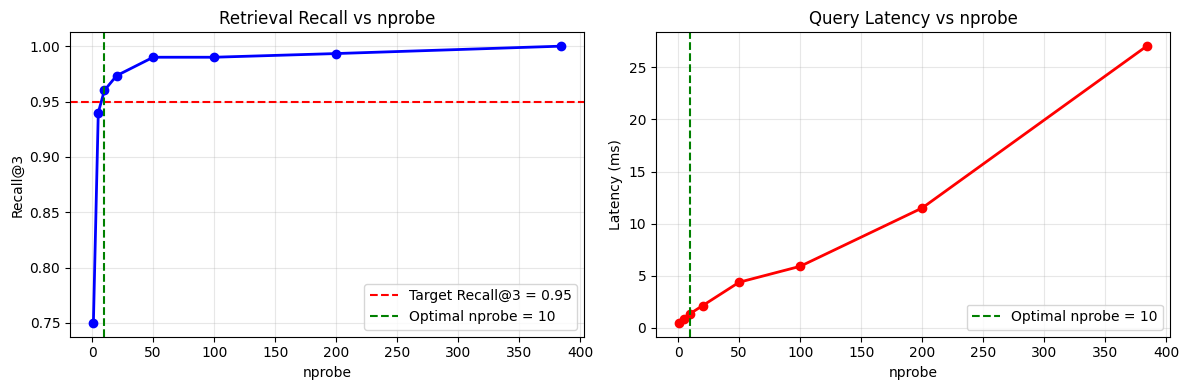


At nprobe=10:
  Recall@3:  0.960
  Recall@10: 0.923
  Latency:   1.38 ms


In [27]:
# ─────────────────────────────────────────────
# Plot Recall@3 and latency vs nprobe
# Helps justify the chosen nprobe value
# ─────────────────────────────────────────────

results = nprobe_data['results']
nprobes  = sorted([int(k) for k in results.keys()])
r3       = [results[str(n)]['recall_at_3']  for n in nprobes]
latency  = [results[str(n)]['latency_ms']   for n in nprobes]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Recall@3
axes[0].plot(nprobes, r3, 'b-o', lw=2, ms=6)
axes[0].axhline(0.95, color='red', ls='--',
                label='Target Recall@3 = 0.95')
axes[0].axvline(optimal_nprobe, color='green', ls='--',
                label=f'Optimal nprobe = {optimal_nprobe}')
axes[0].set_xlabel("nprobe")
axes[0].set_ylabel("Recall@3")
axes[0].set_title("Retrieval Recall vs nprobe")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Latency
axes[1].plot(nprobes, latency, 'r-o', lw=2, ms=6)
axes[1].axvline(optimal_nprobe, color='green', ls='--',
                label=f'Optimal nprobe = {optimal_nprobe}')
axes[1].set_xlabel("nprobe")
axes[1].set_ylabel("Latency (ms)")
axes[1].set_title("Query Latency vs nprobe")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/nprobe_tuning.png", dpi=150)
plt.show()

print(f"\nAt nprobe={optimal_nprobe}:")
r = results[str(optimal_nprobe)]
print(f"  Recall@3:  {r['recall_at_3']:.3f}")
print(f"  Recall@10: {r['recall_at_10']:.3f}")
print(f"  Latency:   {r['latency_ms']:.2f} ms")


#  Quick retrieval sanity check

In [28]:
# ─────────────────────────────────────────────
# Verify FAISS retrieval works correctly
# on known medical questions
# ─────────────────────────────────────────────

from src.retriever import retrieve_faiss

try:
    retriever
except NameError:
    retriever = load_retriever()

test_queries = [
    ("What is the drug of choice for Tuberculosis?",
     "Pharmacology"),
    ("Which nerve is damaged in wrist drop?",
     "Anatomy"),
    ("Drug of choice for malaria in pregnancy?",
     "Pharmacology"),
    ("What causes iron deficiency anaemia?",
     "Pathology"),
    ("What is the mechanism of Metformin?",
     "Pharmacology"),
]

print("RETRIEVAL SANITY CHECK\n")
print(f"{'Query':<50} {'Top Subject':>15} {'Score':>7}")
print("-" * 75)

subject_match = 0
for question, expected_subject in test_queries:
    passages = retrieve_faiss(
        question, faiss_index,
        cleaned_kb_docs, retriever, top_k=3)

    top = passages[0] if passages else {}
    got_subject = top.get('subject', 'None')
    score       = top.get('score', 0)
    match       = "✅" if got_subject == expected_subject \
                   else "⚠️"

    if got_subject == expected_subject:
        subject_match += 1

    print(f"{question[:48]:<50} "
          f"{got_subject[:14]:>15} "
          f"{score:>7.4f} {match}")

print(f"\nSubject match: {subject_match}/{len(test_queries)}")
print(f"Top passage (Query 1):")
p = retrieve_faiss(test_queries[0][0],
                    faiss_index, cleaned_kb_docs,
                    retriever, top_k=1)[0]
print(f"  {p['text'][:150]}...")

RETRIEVAL SANITY CHECK

Query                                                  Top Subject   Score
---------------------------------------------------------------------------
What is the drug of choice for Tuberculosis?            Pediatrics  0.6889 ⚠️
Which nerve is damaged in wrist drop?                      Anatomy  0.7784 ✅
Drug of choice for malaria in pregnancy?            Gynaecology &   0.7884 ⚠️
What causes iron deficiency anaemia?                      Medicine  0.8814 ⚠️
What is the mechanism of Metformin?                        Anatomy  0.6951 ⚠️

Subject match: 1/5
Top passage (Query 1):
  The principles of therapy in children with tuberculosis are similar to that of adults . Medications used for treatment are Isoniazid , Rifampicin , St...


# Build or load BM25 index

In [29]:
# ─────────────────────────────────────────────
# Build BM25 keyword index
#
# BM25 complements FAISS:
#   FAISS: semantic similarity — handles paraphrases
#   BM25:  keyword matching — handles exact terms
#
# Medical questions often use specific drug names,
# anatomical codes, and clinical terms that are
# better matched by exact keywords than semantics.
#
# BM25 is used as CRAG fallback retriever.
# ─────────────────────────────────────────────

if os.path.exists(BM25_INDEX_PATH):
    print("BM25 index already exists — loading\n")
    from src.knowledge_base import load_bm25_index
    bm25_index = load_bm25_index(BM25_INDEX_PATH)
else:
    print("Building BM25 index...\n")
    bm25_index = build_bm25_index(cleaned_kb_docs)
    save_bm25_index(bm25_index, BM25_INDEX_PATH)

# Quick BM25 test
from src.retriever import retrieve_bm25

test_q    = "AHA 2010 guidelines drug resuscitation"
test_opts = ["Atropine", "Amiodarone",
             "Vasopressin", "Epinephrine"]

bm25_results = retrieve_bm25(
    test_q, test_opts, bm25_index,
    cleaned_kb_docs, top_k=3)

print(f"\nBM25 test: '{test_q}'")
print(f"Results:")
for r in bm25_results[:2]:
    print(f"  [{r['subject']}] score={r['score']:.3f}")
    print(f"  {r['text'][:100]}...")

BM25 index already exists — loading

  BM25 index loaded: 290,428 terms

BM25 test: 'AHA 2010 guidelines drug resuscitation'
Results:
  [Medicine] score=42.125
  (Atropine) The use of Atropine for cardiac arrest (PEA / Asystole) has been removed from the ACLS 20...
  [Medicine] score=33.162
  Although VAsopressin is an effective alternative to Epinephrine, it has been removed from the AHA/AC...


#  Final verification

In [31]:
# ─────────────────────────────────────────────
# Verify all Notebook 02 outputs
# ─────────────────────────────────────────────

print("NOTEBOOK 02 — FINAL VERIFICATION\n")

checks = [
    (KB_EMBEDDINGS_PATH,  "kb_embeddings_cleaned.npy",
     True,  f"shape={kb_embeddings.shape}"),
    (FAISS_INDEX_PATH,    "kb_index_cleaned.faiss",
     True,  f"vectors={faiss_index.ntotal:,}"),
    (INDEX_CONFIG_PATH,   "index_config.pkl",
     True,  f"nprobe={index_config['nprobe']}"),
    (BM25_INDEX_PATH,     "bm25_index.pkl",
     True,  f"vocab={len(bm25_index.idf):,}"),
    (NPROBE_RESULTS_PATH, "nprobe_tuning.json",
     True,  f"optimal={optimal_nprobe}"),
]

all_ok = True
for path, label, required, info in checks:
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/(1024**2) \
              if exists else 0
    status = "✅" if exists else "❌"
    if not exists and required:
        all_ok = False
    print(f"  {status} {label:<35} "
          f"{size:>6.1f} MB  {info}")

print()
print(f"Optimal nprobe:    {optimal_nprobe}")
r = nprobe_data['results'][str(optimal_nprobe)]
print(f"Recall@3:          {r['recall_at_3']:.3f}")
print(f"Latency:           {r['latency_ms']:.2f} ms")

print()
if all_ok:
    print("All checks passed ✅")
else:
    print("Some checks failed ❌ — review above")

NOTEBOOK 02 — FINAL VERIFICATION

  ✅ kb_embeddings_cleaned.npy            229.3 MB  shape=(156555, 384)
  ✅ kb_index_cleaned.faiss               231.1 MB  vectors=156,555
  ✅ index_config.pkl                       0.0 MB  nprobe=10
  ✅ bm25_index.pkl                        78.3 MB  vocab=290,428
  ✅ nprobe_tuning.json                     0.0 MB  optimal=10

Optimal nprobe:    10
Recall@3:          0.960
Latency:           1.38 ms

All checks passed ✅
